# American Options — CRR Binomial Tree Pricing

## American vs European options

A **European option** can only be exercised at expiry. An **American option** can be exercised at any time up to and including expiry, giving the holder additional flexibility.

This flexibility has a concrete value called the **early exercise premium**: the difference between the American price and the otherwise-identical European price.

## When is early exercise optimal?

- **American call (no dividends):** Early exercise is *never* optimal. Exercising early surrenders the option's time value and the interest on the strike. The American call therefore prices identically to a European call on a non-dividend-paying underlying.
- **American put:** Early exercise *can* be optimal when the option is deep in-the-money. Exercising captures the strike immediately and earns interest on the proceeds, which can outweigh the remaining time value.

## Cox-Ross-Rubinstein (CRR) binomial tree

The CRR model discretises the underlying's GBM path into a recombining binomial lattice of `n` time steps:

- Up factor: `u = exp(σ √Δt)`
- Down factor: `d = 1 / u`
- Risk-neutral up probability: `p = (exp(r Δt) − d) / (u − d)`

At each interior node the option value is:

```
V = max(intrinsic, discount × (p·V_u + (1-p)·V_d))
```

The `max` enforces early exercise: the holder always chooses the higher of immediate exercise and holding. European pricing skips the `max` and uses the continuation value only.

As `n → ∞` the CRR tree converges to the Black-Scholes price for Europeans and to the true American price for Americans.

In [1]:
%matplotlib inline

from neon.lib.instruments.options.option_inputs import OptionInputs
from neon.lib.instruments.options.option_type import OptionType
from neon.lib.instruments.options.american import AmericanOption
from neon.lib.instruments.options.european import EuropeanOption
from neon.lib.greeks.analytical_greeks import AnalyticalGreeks
import matplotlib.pyplot as plt
import numpy as np

# Shared market parameters
TICKER = "SPX"
SPOT = 100.0
STRIKE = 100.0
VOL = 0.20
RATE = 0.05
CURRENT_DATE = "20250101"
EXPIRY_DATE = "20260101"

## 1. ATM call and put — American vs European

Price an at-the-money call and put under both frameworks and compare.

In [2]:
def make_inputs(spot, strike, option_type):
    return OptionInputs(
        underlying_ticker=TICKER,
        underlying_price=spot,
        strike_price=strike,
        volatility=VOL,
        risk_free_rate=RATE,
        current_date=CURRENT_DATE,
        expiry_date=EXPIRY_DATE,
        option_type=option_type,
    )


call_inputs = make_inputs(SPOT, STRIKE, OptionType.Call)
put_inputs = make_inputs(SPOT, STRIKE, OptionType.Put)

am_call = AmericanOption(call_inputs)
am_put = AmericanOption(put_inputs)
eu_call = EuropeanOption(call_inputs, AnalyticalGreeks())
eu_put = EuropeanOption(put_inputs, AnalyticalGreeks())

print(f"{'':30} {'Call':>10} {'Put':>10}")
print("-" * 52)
print(f"{'American (CRR binomial)':30} {am_call.price():>10.4f} {am_put.price():>10.4f}")
print(f"{'European (Black-Scholes)':30} {eu_call.price():>10.4f} {eu_put.price():>10.4f}")
print("-" * 52)
print(f"{'Early exercise premium':30} {am_call.price() - eu_call.price():>10.4f} {am_put.price() - eu_put.price():>10.4f}")

                                     Call        Put
----------------------------------------------------
American (CRR binomial)           10.4427     6.0872
European (Black-Scholes)          10.4506     5.5735
----------------------------------------------------
Early exercise premium            -0.0079     0.5137


## 2. Early exercise premium across strikes

Sweep the strike from 80 (deep ITM put) to 120 (deep OTM put) and compute the early exercise premium at each point.

The premium is largest for deep in-the-money puts, where the interest earned on immediate exercise dominates the remaining time value.

In [3]:
strikes = np.linspace(80, 120, 41)
premiums_put = []
premiums_call = []

for k in strikes:
    put_in = make_inputs(SPOT, float(k), OptionType.Put)
    call_in = make_inputs(SPOT, float(k), OptionType.Call)

    am_p = AmericanOption(put_in).price()
    eu_p = EuropeanOption(put_in, AnalyticalGreeks()).price()
    am_c = AmericanOption(call_in).price()
    eu_c = EuropeanOption(call_in, AnalyticalGreeks()).price()

    premiums_put.append(am_p - eu_p)
    premiums_call.append(am_c - eu_c)

premiums_put = np.array(premiums_put)
premiums_call = np.array(premiums_call)

print(f"Max put early-exercise premium : {premiums_put.max():.4f} at K={strikes[premiums_put.argmax()]:.0f}")
print(f"Max call early-exercise premium: {premiums_call.max():.4f} (expected ~0 for non-dividend-paying underlying)")

Max put early-exercise premium : 2.7403 at K=120
Max call early-exercise premium: 0.0068 (expected ~0 for non-dividend-paying underlying)


## 3. Plot: early exercise premium vs strike

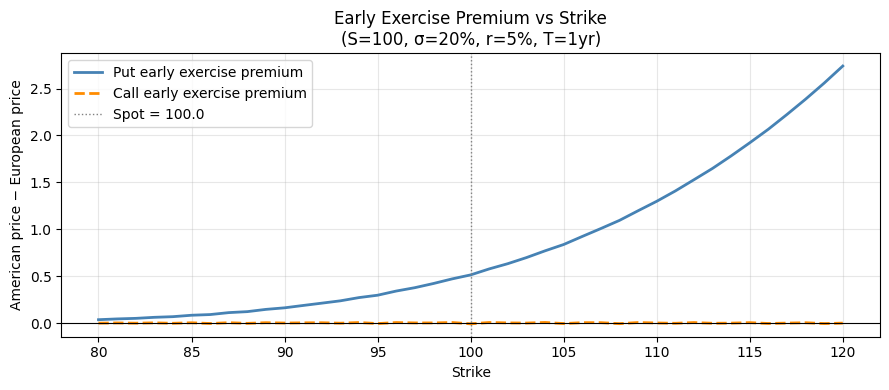

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(strikes, premiums_put, color="steelblue", linewidth=2, label="Put early exercise premium")
ax.plot(strikes, premiums_call, color="darkorange", linewidth=2, linestyle="--", label="Call early exercise premium")
ax.axvline(SPOT, color="gray", linestyle=":", linewidth=1, label=f"Spot = {SPOT}")
ax.axhline(0, color="black", linewidth=0.8)

ax.set_xlabel("Strike")
ax.set_ylabel("American price − European price")
ax.set_title("Early Exercise Premium vs Strike\n(S=100, σ=20%, r=5%, T=1yr)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Plot: American vs European put price vs spot

Sweep spot from 60 to 140 and compare American and European put prices. The gap between the two curves is the early exercise premium, which widens as the put moves deeper in-the-money.

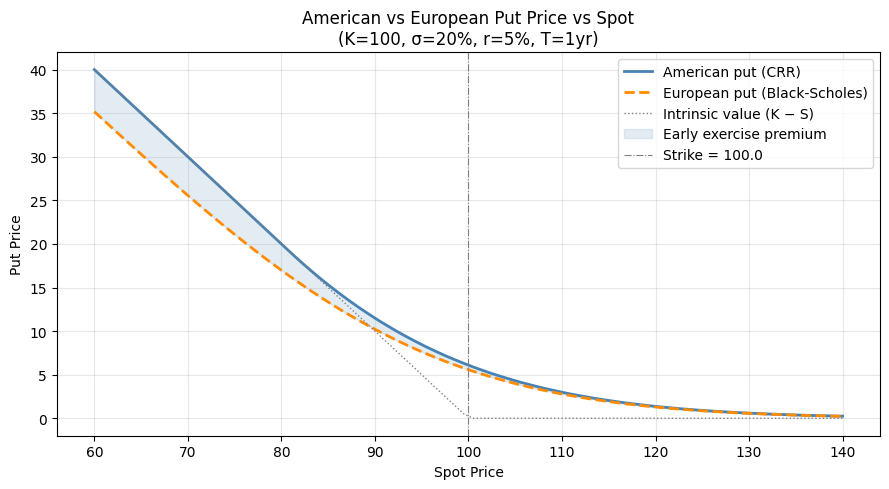

In [5]:
spots = np.linspace(60, 140, 80)
am_put_prices = []
eu_put_prices = []

for s in spots:
    put_in = make_inputs(float(s), STRIKE, OptionType.Put)
    am_put_prices.append(AmericanOption(put_in).price())
    eu_put_prices.append(EuropeanOption(put_in, AnalyticalGreeks()).price())

am_put_prices = np.array(am_put_prices)
eu_put_prices = np.array(eu_put_prices)
intrinsic = np.maximum(STRIKE - spots, 0.0)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(spots, am_put_prices, color="steelblue", linewidth=2, label="American put (CRR)")
ax.plot(spots, eu_put_prices, color="darkorange", linewidth=2, linestyle="--", label="European put (Black-Scholes)")
ax.plot(spots, intrinsic, color="gray", linewidth=1, linestyle=":", label="Intrinsic value (K − S)")
ax.fill_between(spots, eu_put_prices, am_put_prices, alpha=0.15, color="steelblue", label="Early exercise premium")

ax.axvline(STRIKE, color="gray", linestyle="-.", linewidth=0.8, label=f"Strike = {STRIKE}")

ax.set_xlabel("Spot Price")
ax.set_ylabel("Put Price")
ax.set_title("American vs European Put Price vs Spot\n(K=100, σ=20%, r=5%, T=1yr)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()